# Phase 2 — Network Construction

Build weighted directed passing networks for both teams in each of the 5 ground-truth matches, inspect `network_summary`, and draw one team's network with NetworkX (no mplsoccer yet — that is Phase 5).

In [1]:
import os, sys
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../src'))
from tactical_topology import config
from tactical_topology.network import (
    build_passing_network, build_dynamic_network,
    compute_node_positions, network_summary,
)
PROC = os.path.abspath('../data/processed/')
def load(mid):
    return pd.read_parquet(os.path.join(PROC, f'passes_{mid}.parquet'))

## network_summary for every team in all 5 ground-truth matches

In [2]:
rows = []
for mid in config.GROUND_TRUTH_MATCH_IDS:
    df = load(mid)
    for team in df['team'].unique():
        G = build_passing_network(df, team)
        s = network_summary(G)
        s['match_id'] = mid
        s['team'] = team
        s['dyn_steps'] = len(build_dynamic_network(df, team))
        rows.append(s)
summary = pd.DataFrame(rows)[[
    'match_id', 'team', 'n_nodes', 'n_edges', 'density',
    'avg_clustering', 'top_betweenness_node', 'top_eigenvector_node',
    'dyn_steps']]
summary.round(3)

,match_id,team,n_nodes,n_edges,density,avg_clustering,top_betweenness_node,top_eigenvector_node,dyn_steps
0,265839,Barcelona,14,98,0.538,0.627,Gerard Piqué Bernabéu,Neymar da Silva Santos Junior,92
1,265839,Sevilla,13,53,0.340,0.457,Benoît Trémoulinas,Benoît Trémoulinas,91
2,266166,Barcelona,13,100,0.641,0.705,Jordi Alba Ramos,Javier Alejandro Mascherano,92
3,266166,Atlético Madrid,14,62,0.341,0.580,Jorge Resurrección Merodio,Gabriel Fernández Arenas,92
4,266424,Barcelona,14,101,0.555,0.722,Andrés Iniesta Luján,Neymar da Silva Santos Junior,92
5,266424,Real Madrid,13,86,0.551,0.666,Toni Kroos,Toni Kroos,90
6,3825567,Sporting Gijón,14,51,0.280,0.450,Ignacio Cases Mora,Carlos Carmona Bonet,95
7,3825567,Real Madrid,14,101,0.555,0.729,Raphaël Varane,Luka Modrić,94
8,3825563,Las Palmas,14,68,0.374,0.511,David Simón Rodríguez Santana,Antolín Alcáraz Viveros,93
9,3825563,Atlético Madrid,14,87,0.478,0.712,Gabriel Fernández Arenas,Jorge Resurrección Merodio,93


**Sanity checks (PLAN_1.md 2.3):** 10–14 nodes per team, density roughly 0.15–0.60, a clear high-betweenness 'router', and ≥10 dynamic time steps per 90-min match.

## NetworkX draw — El Clásico, Barcelona passing network

Node positions are average pass-origin locations on the pitch (StatsBomb 0–120 × 0–80). Node size ∝ betweenness centrality; the top-betweenness 'router' is highlighted in gold.

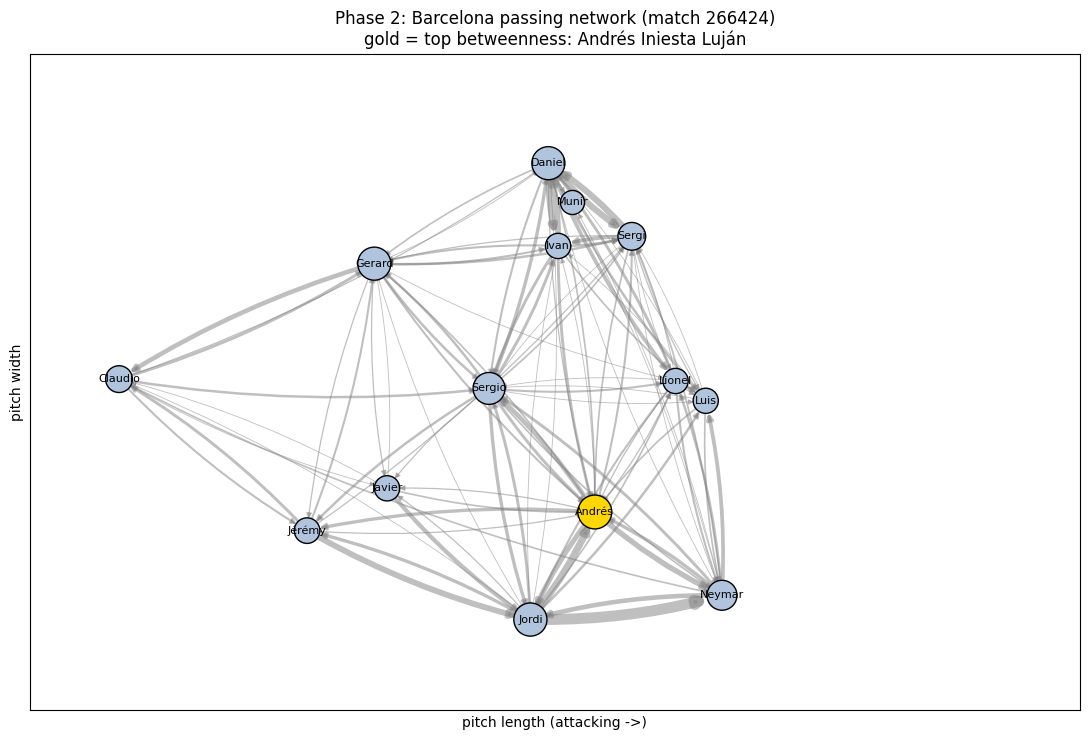

top betweenness: Andrés Iniesta Luján
top eigenvector: Neymar da Silva Santos Junior


In [3]:
MID = 266424  # Real Madrid 0-4 Barcelona
TEAM = 'Barcelona'
df = load(MID)
G = build_passing_network(df, TEAM)
pos = compute_node_positions(df, TEAM)
pos = {n: pos[n] for n in G.nodes() if n in pos}
btw = nx.betweenness_centrality(G)
top = max(btw, key=btw.get)
sizes = [300 + 4000 * btw[n] for n in G.nodes()]
colors = ['gold' if n == top else 'lightsteelblue' for n in G.nodes()]
weights = [d['weight'] for _, _, d in G.edges(data=True)]
fig, ax = plt.subplots(figsize=(11, 7.5))
nx.draw_networkx_edges(G, pos, ax=ax, width=[0.3 * w for w in weights],
                       edge_color='grey', alpha=0.5,
                       arrowsize=8, connectionstyle='arc3,rad=0.07')
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color=colors,
                       edgecolors='black')
labels = {n: n.split()[0] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=8)
ax.set_xlim(0, 120); ax.set_ylim(0, 80)
ax.set_xlabel('pitch length (attacking ->)'); ax.set_ylabel('pitch width')
ax.set_title(f'Phase 2: {TEAM} passing network (match {MID})\n'
             f'gold = top betweenness: {top}')
plt.tight_layout(); plt.show()
print('top betweenness:', top)
print('top eigenvector:', network_summary(G)['top_eigenvector_node'])

## Notes for human verification

- **Node positions** reproduce Barcelona's possession shape: a back line low, midfield triangle, front three high — confirm it looks like a football shape, not a random blob.
- **High-betweenness 'router':** across the marquee teams the top betweenness node is a deep distributor (e.g. Iniesta for Barcelona, Kroos for Real Madrid, Koke/Gabi for Atlético). Note that Busquets-type metronomes are so *uniformly* connected that the bridging role often falls to ball-playing centre-backs / full-backs (e.g. Piqué, Jordi Alba) — this is expected in dense possession networks. Weighted **eigenvector** centrality surfaces the metronomes more directly (Kroos, Modrić, Koke).

**Human approval question:** Does the network structure (shape + key nodes) match your football intuition for these teams?